# Predicting Character Survival in Game of Thrones Using Graph Machine Learning

В этом проекте исследуется возможность прогнозирования выживания персонажей цикла «Песнь Льда и Огня» на основе структуры графа их взаимодействий.

Основная идея исследования — проверить, насколько различные графовые признаки помогают предсказывать судьбу персонажей.

Рассматриваются следующие подходы:

- классические графовые центральности;
- Node2Vec;
- гибридные признаки;
- временные (temporal) признаки.

## 1. Import Libraries

Импорт необходимых библиотек и модулей проекта.

In [1]:
import sys
from pathlib import Path

import pandas as pd
import numpy as np
import scipy.stats as stats

project_root = Path().resolve().parent
sys.path.append(str(project_root))
 
from src.graph import build_graph, basic_stats, build_graphs_by_book, build_cumulative_graph
from src.features import extract_features, extract_temporal_features, aggregate_temporal_features, add_trend_features
from src.data_loader import load_edges, load_all_edges, load_node_labels
from src.node_embeddings import generate_node2vec_embeddings

import joblib
from pathlib import Path
import matplotlib.pyplot as plt
import networkx as nx

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.dummy import DummyClassifier
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate, cross_val_predict
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import make_scorer, recall_score, f1_score, precision_score, classification_report, confusion_matrix, ConfusionMatrixDisplay, balanced_accuracy_score

## 2. Load Interaction Data

Загружаются все взаимодействия персонажей из пяти книг.

In [2]:
df = load_all_edges()

## 3. Exploratory Data Analysis

Первичный анализ структуры исходного датасета.

In [3]:
df.head()

,Source,Target,Type,weight,book
0,Addam-Marbrand,Jaime-Lannister,Undirected,3,1
1,Addam-Marbrand,Tywin-Lannister,Undirected,6,1
2,Aegon-I-Targaryen,Daenerys-Targaryen,Undirected,5,1
3,Aegon-I-Targaryen,Eddard-Stark,Undirected,4,1
4,Aemon-Targaryen-(Maester-Aemon),Alliser-Thorne,Undirected,4,1


## 4. Build Character Interaction Graph

Построение графа взаимодействий персонажей.

In [4]:
G = build_graphs_by_book(df)

print(G)

{1: <networkx.classes.graph.Graph object at 0x00000149C21CD4C8>, 2: <networkx.classes.graph.Graph object at 0x00000149E6493548>, 3: <networkx.classes.graph.Graph object at 0x00000149E6837E88>, 4: <networkx.classes.graph.Graph object at 0x00000149C21C8F88>, 5: <networkx.classes.graph.Graph object at 0x00000149E684F388>}


In [5]:
print(df["book"].value_counts())

3    1008
2     775
5     760
1     684
4     682
Name: book, dtype: int64


In [6]:
df = df.drop(columns = ['Type'], axis = 0)

In [7]:
print(df.columns)

Index(['Source', 'Target', 'weight', 'book'], dtype='object')


In [8]:
graphs = build_graphs_by_book(df)

In [9]:
labels = load_node_labels()

## 5. Extract Graph Features

Для каждого персонажа рассчитываются:

- Degree Centrality
- Weighted Degree
- Betweenness
- PageRank
- Clustering Coefficient

In [10]:
G_4 = build_cumulative_graph(df, max_book=4)
features_4 = extract_features(G_4)

In [11]:
print(features_4.shape)
features_4.head()

(646, 6)


,node,degree_centrality,weighted_degree,betweenness,pagerank,clustering
0,Addam-Marbrand,0.018605,50,0.000676,0.001407,0.037348
1,Jaime-Lannister,0.151938,764,0.120818,0.021322,0.011139
2,Tywin-Lannister,0.069767,282,0.025470,0.007251,0.024622
3,Aegon-I-Targaryen,0.013953,32,0.008578,0.001575,0.008500
4,Daenerys-Targaryen,0.062016,444,0.068887,0.013529,0.014024


In [12]:
labels["name"] = labels["name"].astype(str).str.strip()
labels.head()

,name,isAlive
0,Viserys II Targaryen,0
1,Walder Frey,1
2,Addison Hill,1
3,Aemma Arryn,0
4,Sylva Santagar,1


In [13]:
labels.columns = (
    labels.columns
    .astype(str)
    .str.strip()
    .str.replace("\ufeff", "", regex=False)
)

features_4["node"] = features_4["node"].astype(str).str.strip()

print(labels.columns.tolist())

['name', 'isAlive']


In [14]:
labels = labels.rename(columns={
    "name": "Name",
    "character": "Name",
    "Character": "Name"
})

labels["Name"] = labels["Name"].astype(str).str.strip()

## 6. Build Machine Learning Dataset

Объединение графовых признаков с информацией о выживании персонажей.

In [15]:
dataset_4 = features_4.merge(
    labels,
    left_on="node",
    right_on="Name",
    how="inner"
)

print(dataset_4.shape)
dataset_4.head()

(154, 8)


,node,degree_centrality,weighted_degree,betweenness,pagerank,clustering,Name,isAlive
0,Chett,0.010853,44,0.000124,0.001425,0.057334,Chett,0
1,Aggo,0.010853,33,0.000025,0.001131,0.051796,Aggo,1
2,Jhogo,0.012403,38,0.000014,0.001247,0.045558,Jhogo,1
3,Quaro,0.007752,21,0.000002,0.000823,0.048424,Quaro,0
4,Albett,0.004651,11,0.000000,0.000515,0.046142,Albett,1


In [16]:
print(dataset_4["isAlive"].value_counts())

1    98
0    56
Name: isAlive, dtype: int64


In [17]:
X = dataset_4.drop(columns=["node", "Name", "isAlive"], errors="ignore")
y = dataset_4["isAlive"]

print(X.shape)
print(y.value_counts())
print(X.columns.tolist())

(154, 5)
1    98
0    56
Name: isAlive, dtype: int64
['degree_centrality', 'weighted_degree', 'betweenness', 'pagerank', 'clustering']


In [18]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scoring = {
    "accuracy": "accuracy",
    "balanced_accuracy": "balanced_accuracy",
    "f1_macro": "f1_macro",
    "precision_macro": make_scorer(precision_score, average="macro", zero_division=0),
    "recall_macro": "recall_macro",
    "recall_dead": make_scorer(recall_score, pos_label=0),
    "f1_dead": make_scorer(f1_score, pos_label=0, zero_division=0)
    }

## 7. Baseline Model

Построение простой базовой модели для сравнения.

In [19]:
models = {
    "baseline_most_frequent": DummyClassifier(strategy="most_frequent"),
    
    "random_forest": RandomForestClassifier(
        n_estimators=200,
        max_depth=5,
        random_state=42,
        class_weight="balanced"
    ),
    
    "logistic_regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(
            class_weight="balanced",
            max_iter=2000,
            random_state=42
        ))
    ])
}

In [20]:
def evaluate_model_cv(model, X, y, cv, scoring):
    cv_results = cross_validate(
        model,
        X,
        y,
        cv=cv,
        scoring=scoring,
        return_train_score=False,
        n_jobs=None
    )
    
    summary = {}
    for metric_name, values in cv_results.items():
        if metric_name.startswith("test_"):
            clean_name = metric_name.replace("test_", "")
            summary[f"{clean_name}_mean"] = values.mean()
            summary[f"{clean_name}_std"] = values.std()
    
    return pd.Series(summary)

In [21]:
cv_summary = pd.DataFrame({
    model_name: evaluate_model_cv(model, X, y, cv, scoring)
    for model_name, model in models.items()
}).T

cv_summary

,accuracy_mean,accuracy_std,balanced_accuracy_mean,balanced_accuracy_std,f1_macro_mean,f1_macro_std,precision_macro_mean,precision_macro_std,recall_macro_mean,recall_macro_std,recall_dead_mean,recall_dead_std,f1_dead_mean,f1_dead_std
baseline_most_frequent,0.636344,0.012584,0.500000,0.000000,0.388845,0.004740,0.318172,0.006292,0.500000,0.000000,0.000000,0.000000,0.000000,0.000000
random_forest,0.506667,0.053696,0.452073,0.046135,0.446925,0.047481,0.448086,0.050964,0.452073,0.046135,0.251515,0.071453,0.268293,0.060508
logistic_regression,0.486237,0.069447,0.479242,0.084409,0.469701,0.074559,0.479740,0.078577,0.479242,0.084409,0.448485,0.156171,0.381589,0.103624


In [22]:
cv_summary.sort_values("f1_macro_mean", ascending=False)

,accuracy_mean,accuracy_std,balanced_accuracy_mean,balanced_accuracy_std,f1_macro_mean,f1_macro_std,precision_macro_mean,precision_macro_std,recall_macro_mean,recall_macro_std,recall_dead_mean,recall_dead_std,f1_dead_mean,f1_dead_std
logistic_regression,0.486237,0.069447,0.479242,0.084409,0.469701,0.074559,0.479740,0.078577,0.479242,0.084409,0.448485,0.156171,0.381589,0.103624
random_forest,0.506667,0.053696,0.452073,0.046135,0.446925,0.047481,0.448086,0.050964,0.452073,0.046135,0.251515,0.071453,0.268293,0.060508
baseline_most_frequent,0.636344,0.012584,0.500000,0.000000,0.388845,0.004740,0.318172,0.006292,0.500000,0.000000,0.000000,0.000000,0.000000,0.000000


## 8. Random Forest

Обучение Random Forest на графовых признаках.

Для оценки используется Stratified K-Fold Cross Validation.

In [23]:
rf_cv_results = cross_validate(
    models["random_forest"],
    X,
    y,
    cv=cv,
    scoring=scoring,
    return_train_score=False
)

pd.DataFrame(rf_cv_results)

,fit_time,score_time,test_accuracy,test_balanced_accuracy,test_f1_macro,test_precision_macro,test_recall_macro,test_recall_dead,test_f1_dead
0,0.110018,0.008999,0.419355,0.372807,0.365909,0.361905,0.372807,0.166667,0.181818
1,0.104492,0.009093,0.483871,0.456818,0.456140,0.459402,0.456818,0.363636,0.333333
2,0.099077,0.007913,0.580645,0.511364,0.506732,0.513587,0.511364,0.272727,0.315789
3,0.106460,0.009999,0.516129,0.440909,0.430845,0.429348,0.440909,0.181818,0.210526
4,0.109235,0.010011,0.533333,0.478469,0.475000,0.476190,0.478469,0.272727,0.300000


In [24]:
feature_sets = {
    "all_features": [
        "degree_centrality",
        "weighted_degree",
        "betweenness",
        "pagerank",
        "clustering"
    ],
    "without_clustering": [
        "degree_centrality",
        "weighted_degree",
        "betweenness",
        "pagerank"
    ],
    "top_2_importance": [
        "pagerank",
        "weighted_degree"
    ],
    "top_3_importance": [
        "pagerank",
        "weighted_degree",
        "clustering"
    ]
}

In [25]:
feature_set_results = {}

for set_name, columns in feature_sets.items():
    X_subset = X[columns]
    feature_set_results[set_name] = evaluate_model_cv(
        models["random_forest"],
        X_subset,
        y,
        cv,
        scoring
    )

feature_set_summary = pd.DataFrame(feature_set_results).T
feature_set_summary.sort_values("f1_macro_mean", ascending=False)

,accuracy_mean,accuracy_std,balanced_accuracy_mean,balanced_accuracy_std,f1_macro_mean,f1_macro_std,precision_macro_mean,precision_macro_std,recall_macro_mean,recall_macro_std,recall_dead_mean,recall_dead_std,f1_dead_mean,f1_dead_std
top_2_importance,0.571613,0.067616,0.528166,0.083425,0.518304,0.093587,0.517919,0.094686,0.528166,0.083425,0.362121,0.174893,0.363356,0.155388
top_3_importance,0.545376,0.035846,0.501770,0.038540,0.499994,0.039815,0.500388,0.040056,0.501770,0.038540,0.340909,0.073293,0.350420,0.057969
all_features,0.506667,0.053696,0.452073,0.046135,0.446925,0.047481,0.448086,0.050964,0.452073,0.046135,0.251515,0.071453,0.268293,0.060508
without_clustering,0.480645,0.085590,0.443820,0.089818,0.441839,0.088156,0.442832,0.087146,0.443820,0.089818,0.306061,0.126549,0.297068,0.109419


In [26]:
candidate_feature_sets = {
    "all_features": [
        "degree_centrality",
        "weighted_degree",
        "betweenness",
        "pagerank",
        "clustering"
    ],
    "top_2_importance": [
        "pagerank",
        "weighted_degree"
    ],
    "top_3_importance": [
        "pagerank",
        "weighted_degree",
        "clustering"
    ]
}

In [27]:
candidate_models = {
    "random_forest": RandomForestClassifier(
        n_estimators=200,
        max_depth=5,
        random_state=42,
        class_weight="balanced"
    ),
    "logistic_regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(
            class_weight="balanced",
            max_iter=2000,
            random_state=42
        ))
    ])
}

In [28]:
comparison_results = []

for feature_set_name, columns in candidate_feature_sets.items():
    X_subset = X[columns]
    
    for model_name, model in candidate_models.items():
        result = evaluate_model_cv(model, X_subset, y, cv, scoring)
        result["model"] = model_name
        result["feature_set"] = feature_set_name
        comparison_results.append(result)

comparison_df = pd.DataFrame(comparison_results)
comparison_df = comparison_df.set_index(["model", "feature_set"]).sort_values(
    "f1_macro_mean", ascending=False
)

comparison_df

accuracy_mean  accuracy_std  \
model               feature_set                                     
random_forest       top_2_importance       0.571613      0.067616   
                    top_3_importance       0.545376      0.035846   
logistic_regression top_3_importance       0.499570      0.038898   
                    all_features           0.486237      0.069447   
random_forest       all_features           0.506667      0.053696   
logistic_regression top_2_importance       0.357634      0.086417   

                                      balanced_accuracy_mean  \
model               feature_set                                
random_forest       top_2_importance                0.528166   
                    top_3_importance                0.501770   
logistic_regression top_3_importance                0.493596   
                    all_features                    0.479242   
random_forest       all_features                    0.452073   
logistic_regression top_2_importance                0.382544   

                                      balanced_accuracy_std  f1_macro_mean  \
model               feature_set                                              
random_forest       top_2_importance               0.083425       0.518304   
                    top_3_importance               0.038540       0.499994   
logistic_regression top_3_importance               0.049965       0.484202   
                    all_features                   0.084409       0.469701   
random_forest       all_features                   0.046135       0.446925   
logistic_regression top_2_importance               0.087598       0.346644   

                                      f1_macro_std  precision_macro_mean  \
model               feature_set                                            
random_forest       top_2_importance      0.093587              0.517919   
                    top_3_importance      0.039815              0.500388   
logistic_regression top_3_importance      0.042584              0.493339   
                    all_features          0.074559              0.479740   
random_forest       all_features          0.047481              0.448086   
logistic_regression top_2_importance      0.084667              0.372734   

                                      precision_macro_std  recall_macro_mean  \
model               feature_set                                                
random_forest       top_2_importance             0.094686           0.528166   
                    top_3_importance             0.040056           0.501770   
logistic_regression top_3_importance             0.046964           0.493596   
                    all_features                 0.078577           0.479242   
random_forest       all_features                 0.050964           0.452073   
logistic_regression top_2_importance             0.093097           0.382544   

                                      recall_macro_std  recall_dead_mean  \
model               feature_set                                            
random_forest       top_2_importance          0.083425          0.362121   
                    top_3_importance          0.038540          0.340909   
logistic_regression top_3_importance          0.049965          0.466667   
                    all_features              0.084409          0.448485   
random_forest       all_features              0.046135          0.251515   
logistic_regression top_2_importance          0.087598          0.466667   

                                      recall_dead_std  f1_dead_mean  \
model               feature_set                                       
random_forest       top_2_importance         0.174893      0.363356   
                    top_3_importance         0.073293      0.350420   
logistic_regression top_3_importance         0.112734      0.399526   
                    all_features             0.156171      0.381589   
random_forest       all_features             0.071453      0.2

In [104]:
models = list(comparison_df.keys())
scores = list(comparison_df.values())

plt.figure(figsize=(9, 5))

bars = plt.bar(models, scores)

plt.title("Model Comparison")
plt.ylabel("Macro score")
plt.ylim(0, 0.65)

# Подписываем значения над столбцами
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.01,
        f"{height:.3f}",
        ha="center",
        fontsize=10
    )

plt.grid(axis="y", alpha=0.3)

plt.tight_layout()

plt.savefig(
    "../reports/figures/model_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

TypeError: 'numpy.ndarray' object is not callable

In [29]:
final_feature_columns = ["pagerank", "weighted_degree"]
X_final = X[final_feature_columns]

In [30]:
final_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        class_weight="balanced",
        max_iter=2000,
        random_state=42
    ))
])

oof_pred = cross_val_predict(final_model, X_final, y, cv=cv)

print(classification_report(y, oof_pred))
print(confusion_matrix(y, oof_pred))

              precision    recall  f1-score   support

           0       0.27      0.46      0.34        56
           1       0.49      0.30      0.37        98

    accuracy                           0.36       154
   macro avg       0.38      0.38      0.36       154
weighted avg       0.41      0.36      0.36       154

[[26 30]
 [69 29]]


In [31]:
final_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=5,
    random_state=42,
    class_weight="balanced"
)

final_model.fit(X_final, y)

RandomForestClassifier(class_weight='balanced', max_depth=5, n_estimators=200,
                       random_state=42)

In [32]:
artifacts_dir = Path("../artifacts")
artifacts_dir.mkdir(exist_ok=True)

joblib.dump(final_model, artifacts_dir / "final_model.joblib")
joblib.dump(final_feature_columns, artifacts_dir / "final_feature_columns.joblib")

['..\\artifacts\\final_feature_columns.joblib']

In [33]:
dataset_4.to_csv(artifacts_dir / "dataset_4.csv", index=False)
comparison_df.to_csv(artifacts_dir / "model_comparison.csv")

In [34]:
figures_dir = Path("../reports/figures")
figures_dir.mkdir(exist_ok=True)

           feature  importance
0         pagerank    0.579953
1  weighted_degree    0.420047


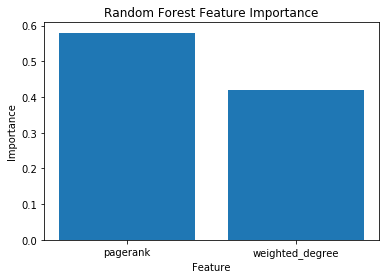

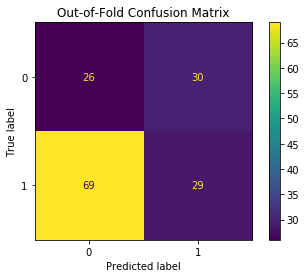

In [35]:
importance_df = pd.DataFrame({
    "feature": final_feature_columns,
    "importance": final_model.feature_importances_
}).sort_values("importance", ascending=False)

print(importance_df)

plt.figure(figsize=(6, 4))

plt.bar(
    importance_df["feature"],
    importance_df["importance"]
)

plt.xlabel("Feature")
plt.ylabel("Importance")
plt.title("Random Forest Feature Importance")

plt.show()

ConfusionMatrixDisplay.from_predictions(
    y,
    oof_pred
)

plt.title("Out-of-Fold Confusion Matrix")

plt.savefig(figures_dir / "out_of_fold_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

           feature  importance
0         pagerank    0.579953
1  weighted_degree    0.420047


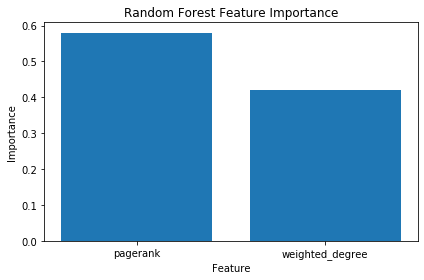

In [36]:
importance_df = pd.DataFrame({
    "feature": final_feature_columns,
    "importance": final_model.feature_importances_
}).sort_values("importance", ascending=False)

print(importance_df)

plt.figure(figsize=(6, 4))

plt.bar(
    importance_df["feature"],
    importance_df["importance"]
)

plt.xlabel("Feature")
plt.ylabel("Importance")
plt.title("Random Forest Feature Importance")

plt.tight_layout()

plt.savefig(
    figures_dir / "rf_feature_importance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [37]:
alive = dataset_4[dataset_4["isAlive"] == 1]
dead = dataset_4[dataset_4["isAlive"] == 0]

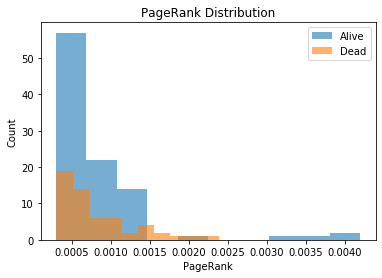

In [38]:
plt.figure(figsize=(6, 4))

plt.hist(
    alive["pagerank"],
    alpha=0.6,
    label="Alive"
)

plt.hist(
    dead["pagerank"],
    alpha=0.6,
    label="Dead"
)

plt.xlabel("PageRank")
plt.ylabel("Count")
plt.title("PageRank Distribution")

plt.savefig(
    figures_dir / "pagerank_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.legend()
plt.show()

In [39]:
G = build_graph(df)

pagerank = nx.pagerank(G)

node_sizes = [
    pagerank[node] * 50000
    for node in G.nodes()
]

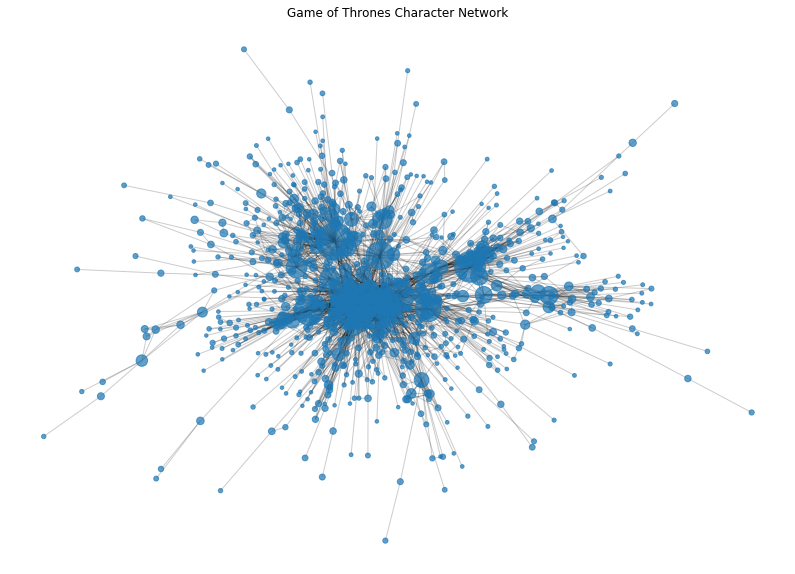

In [40]:
plt.figure(figsize=(14, 10))

pos = nx.spring_layout(G, seed=42)

nx.draw_networkx_nodes(
    G,
    pos,
    node_size=node_sizes,
    alpha=0.7
)

nx.draw_networkx_edges(
    G,
    pos,
    alpha=0.2
)

plt.title("Game of Thrones Character Network")

plt.axis("off")

plt.savefig(
    figures_dir / "network.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 10. Node2Vec Embeddings

Исследование эмбеддингов графа.

In [41]:
embeddings = generate_node2vec_embeddings(
    G,
    dimensions=64,
    workers=8
)

embeddings.head()

,node,emb_0,emb_1,emb_2,emb_3,emb_4,emb_5,emb_6,emb_7,emb_8,...,emb_54,emb_55,emb_56,emb_57,emb_58,emb_59,emb_60,emb_61,emb_62,emb_63
0,Addam-Marbrand,0.111206,-0.058214,-0.094169,0.257028,0.082529,-0.613153,-0.210866,0.158088,-0.501476,...,-0.031267,-0.297203,0.230589,-0.057492,-0.312884,-0.182657,0.000852,-0.448456,0.314096,-0.615855
1,Jaime-Lannister,0.126790,-0.573762,-0.226554,0.122091,-0.039514,-0.071352,-0.082760,0.176911,-0.287715,...,0.007431,0.047341,0.308976,-0.180376,-0.024095,0.102151,0.173539,-0.389711,0.019582,-0.341792
2,Tywin-Lannister,0.495830,-0.152504,0.102971,-0.438200,-0.003266,-0.630065,-0.179607,0.017258,-0.567674,...,-0.092803,-0.404203,0.112455,-0.009172,0.077988,-0.377172,0.054093,-0.237705,-0.203928,-0.607964
3,Aegon-I-Targaryen,0.215615,0.064006,0.552890,0.054836,-0.215806,-0.473193,0.229399,-0.646820,-0.145629,...,-0.149000,-0.338009,0.653488,-0.466887,0.071531,0.053980,-0.212039,-0.107899,-0.176991,-0.165129
4,Daenerys-Targaryen,0.393805,0.090122,0.012981,0.095984,-0.072704,-0.573191,-0.034830,-0.489477,-0.424744,...,0.141197,-0.081438,0.045152,-0.565327,-0.273563,-0.543654,0.139420,0.131085,0.319916,-0.201626


In [42]:
print(df.shape)

df.head()

(3909, 4)


,Source,Target,weight,book
0,Addam-Marbrand,Jaime-Lannister,3,1
1,Addam-Marbrand,Tywin-Lannister,6,1
2,Aegon-I-Targaryen,Daenerys-Targaryen,5,1
3,Aegon-I-Targaryen,Eddard-Stark,4,1
4,Aemon-Targaryen-(Maester-Aemon),Alliser-Thorne,4,1


In [43]:
df["book"].value_counts().sort_index()

1     684
2     775
3    1008
4     682
5     760
Name: book, dtype: int64

In [44]:
G_train = build_cumulative_graph(df, max_book=4)

print("Nodes:", G_train.number_of_nodes())
print("Edges:", G_train.number_of_edges())

Nodes: 646
Edges: 2307


In [45]:
embeddings = generate_node2vec_embeddings(G_train)

print(embeddings.shape)

embeddings.head()


(646, 33)


,node,emb_0,emb_1,emb_2,emb_3,emb_4,emb_5,emb_6,emb_7,emb_8,...,emb_22,emb_23,emb_24,emb_25,emb_26,emb_27,emb_28,emb_29,emb_30,emb_31
0,Addam-Marbrand,-0.051240,-1.415612,0.406974,0.090228,-0.251572,-0.091232,0.719292,1.128984,0.254417,...,0.278673,0.193206,-0.313923,0.497076,-0.594148,0.240716,0.062588,0.079380,0.166296,-0.147790
1,Jaime-Lannister,-0.287592,-0.973238,-0.009079,0.244394,-0.249028,0.358673,0.585587,0.605307,0.259852,...,0.086351,-0.071065,-0.056402,-0.391413,-0.049904,0.365360,-0.197671,-0.128602,0.078153,0.120217
2,Tywin-Lannister,-0.303547,-0.740327,-0.021860,-0.150963,-0.382514,-0.185347,-0.085389,0.456758,-0.009837,...,0.449205,0.187592,0.293745,0.460595,-0.511593,-0.052297,-0.446196,-0.049648,0.308761,-0.312123
3,Aegon-I-Targaryen,-0.647739,-0.480384,-0.055867,-0.828100,-0.016783,-0.835644,0.989939,-0.004335,-0.618398,...,1.218475,0.067803,0.630929,0.709981,-0.159364,-0.407558,0.691755,-0.468481,0.521415,-0.211754
4,Daenerys-Targaryen,-0.063284,-0.611235,-0.406290,-0.028413,0.467086,-0.924850,1.284991,0.251330,-0.854674,...,0.868112,-0.244348,0.314819,-0.003253,-1.446671,-0.269054,0.298934,-0.642261,-0.245309,-0.023976


In [46]:
dataset_emb = embeddings.merge(
    labels,
    left_on="node",
    right_on="Name",
    how="inner"
)

In [47]:
print(dataset_emb.shape)

(154, 35)


In [48]:
X_emb = dataset_emb.drop(
    columns=["node", "Name", "isAlive"]
)

y_emb = dataset_emb["isAlive"]

print(X_emb.shape)

(154, 32)


In [49]:
rf_emb = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    class_weight="balanced"
)

In [50]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [51]:
oof_pred_emb = cross_val_predict(
    rf_emb,
    X_emb,
    y_emb,
    cv=cv
)

In [52]:
print(classification_report(
    y_emb,
    oof_pred_emb
))

              precision    recall  f1-score   support

           0       0.28      0.20      0.23        56
           1       0.61      0.71      0.66        98

    accuracy                           0.53       154
   macro avg       0.45      0.46      0.44       154
weighted avg       0.49      0.53      0.50       154



In [53]:
balanced_acc_emb = balanced_accuracy_score(
    y_emb,
    oof_pred_emb
)

macro_f1_emb = f1_score(
    y_emb,
    oof_pred_emb,
    average="macro"
)

print("Balanced Accuracy:", balanced_acc_emb)
print("Macro F1:", macro_f1_emb)

Balanced Accuracy: 0.45535714285714285
Macro F1: 0.4444279713367927


In [54]:
results = [{
    "experiment": "Node2Vec + RF",
    "balanced_accuracy": balanced_acc_emb,
    "macro_f1": macro_f1_emb
}]

In [55]:
results_df = pd.DataFrame(results)

results_df.sort_values(
    "macro_f1",
    ascending=False
)

,experiment,balanced_accuracy,macro_f1
0,Node2Vec + RF,0.455357,0.444428


## 11. Hybrid Features

Объединение эмбеддингов Node2Vec и классических графовых признаков.

In [56]:
emb_cols = [
    c
    for c in dataset_emb.columns
    if c.startswith("emb_")
]

In [57]:
hybrid_dataset = dataset_4.merge(
    dataset_emb[["node"] + emb_cols],
    on="node",
    how="inner"
)

In [58]:
print(hybrid_dataset.shape)

(154, 40)


In [59]:
X_hybrid = hybrid_dataset.drop(
    columns=["node", "Name", "isAlive"],
    errors="ignore"
)

y_hybrid = hybrid_dataset["isAlive"]

In [60]:
rf_hybrid = RandomForestClassifier(
    n_estimators=300,
    class_weight="balanced",
    random_state=42
)

In [61]:
oof_pred_hybrid = cross_val_predict(
    rf_hybrid,
    X_hybrid,
    y_hybrid,
    cv=cv
)

In [62]:
balanced_acc_hybrid = balanced_accuracy_score(
    y_hybrid,
    oof_pred_hybrid
)

macro_f1_hybrid = f1_score(
    y_hybrid,
    oof_pred_hybrid,
    average="macro"
)

print("Balanced Accuracy:", balanced_acc_hybrid)
print("Macro F1:", macro_f1_hybrid)
print(classification_report(y_hybrid, oof_pred_hybrid))

Balanced Accuracy: 0.514030612244898
Macro F1: 0.5022317992919809
              precision    recall  f1-score   support

           0       0.39      0.23      0.29        56
           1       0.64      0.80      0.71        98

    accuracy                           0.59       154
   macro avg       0.52      0.51      0.50       154
weighted avg       0.55      0.59      0.56       154



In [63]:
results.append({
    "experiment": "Hybrid Features + RF",
    "balanced_accuracy": balanced_acc_hybrid,
    "macro_f1": macro_f1_hybrid
})

In [64]:
results.append({
    "experiment": "Hybrid Features + RF",
    "balanced_accuracy": balanced_acc_hybrid,
    "macro_f1": macro_f1_hybrid
})

In [65]:
results_df = pd.DataFrame(results)

results_df.sort_values(
    by="macro_f1",
    ascending=False
)

,experiment,balanced_accuracy,macro_f1
1,Hybrid Features + RF,0.514031,0.502232
2,Hybrid Features + RF,0.514031,0.502232
0,Node2Vec + RF,0.455357,0.444428


In [66]:
print(hybrid_dataset.shape)

(154, 40)


## 12. Temporal Graph Analysis

Для каждой книги строится отдельный граф.

Извлекаются временные признаки:

- PageRank
- Betweenness
- их изменения между книгами.

In [67]:
G3 = build_cumulative_graph(df, max_book=3)
G4 = build_cumulative_graph(df, max_book=4)

In [68]:
print(G3.number_of_nodes(), G3.number_of_edges())
print(G4.number_of_nodes(), G4.number_of_edges())

498 1849
646 2307


In [69]:
graphs_by_book = {}

for book in range(1, 5):
    graphs_by_book[book] = build_cumulative_graph(
        df,
        max_book=book
    )

In [70]:
for book, G in graphs_by_book.items():
    print(
        f"Book {book}:",
        G.number_of_nodes(),
        "nodes,",
        G.number_of_edges(),
        "edges"
    )

Book 1: 187 nodes, 684 edges
Book 2: 356 nodes, 1234 edges
Book 3: 498 nodes, 1849 edges
Book 4: 646 nodes, 2307 edges


In [71]:
graphs_by_book = {}

for book in range(1, 5):
    graphs_by_book[book] = build_cumulative_graph(
        df,
        max_book=book
    )

temporal_df = extract_temporal_features(
    graphs_by_book
)

In [72]:
temporal_df["pagerank"].describe()

count    1687.000000
mean        0.002371
std         0.004717
min         0.000293
25%         0.000588
50%         0.001055
75%         0.002099
max         0.072362
Name: pagerank, dtype: float64

In [73]:
temporal_df["betweenness"].describe()

count    1687.000000
mean        0.005227
std         0.020409
min         0.000000
25%         0.000000
50%         0.000005
75%         0.001285
max         0.269604
Name: betweenness, dtype: float64

In [74]:
print(temporal_df.shape)

temporal_df.head()

(1687, 5)


,node,book,weighted_degree,betweenness,pagerank
0,Addam-Marbrand,1,9,0.00000,0.001276
1,Jaime-Lannister,1,241,0.03201,0.014403
2,Tywin-Lannister,1,181,0.02619,0.011424
3,Aegon-I-Targaryen,1,9,0.00000,0.001254
4,Daenerys-Targaryen,1,443,0.08627,0.027099


In [75]:
pagerank_wide = temporal_df.pivot(
    index="node",
    columns="book",
    values="pagerank"
)

In [76]:
pagerank_wide.columns = [
    f"pagerank_{col}"
    for col in pagerank_wide.columns
]

In [77]:
pagerank_wide.head()

,pagerank_1,pagerank_2,pagerank_3,pagerank_4
node,,,,
Addam-Marbrand,0.001276,0.000751,0.001297,0.001407
Aegon-Frey-(son-of-Stevron),NaN,NaN,0.000881,0.000711
Aegon-I-Targaryen,0.001254,0.002359,0.001952,0.001575
Aegon-Targaryen-(son-of-Rhaegar),NaN,NaN,0.000402,0.000386
Aegon-V-Targaryen,NaN,0.000632,0.000391,0.000308


In [78]:
pagerank_wide["pagerank_delta_34"] = (
    pagerank_wide["pagerank_4"]
    - pagerank_wide["pagerank_3"]
)

pagerank_wide["pagerank_delta_23"] = (
    pagerank_wide["pagerank_3"]
    - pagerank_wide["pagerank_2"]
)

pagerank_wide["pagerank_delta_12"] = (
    pagerank_wide["pagerank_2"]
    - pagerank_wide["pagerank_1"]
)

In [79]:
betweenness_wide = temporal_df.pivot(
    index="node",
    columns="book",
    values="betweenness"
)

betweenness_wide.columns = [
    f"betweenness_{col}"
    for col in betweenness_wide.columns
]

betweenness_wide["betweenness_delta_34"] = (
    betweenness_wide["betweenness_4"]
    - betweenness_wide["betweenness_3"]
)

betweenness_wide["betweenness_delta_23"] = (
    betweenness_wide["betweenness_3"]
    - betweenness_wide["betweenness_2"]
)

betweenness_wide["betweenness_delta_12"] = (
    betweenness_wide["betweenness_2"]
    - betweenness_wide["betweenness_1"]
)



In [80]:
temporal_features_wide = pagerank_wide.merge(
    betweenness_wide,
    left_index=True,
    right_index=True
)

In [81]:
temporal_features_wide = temporal_features_wide.reset_index()

print(temporal_features_wide.shape)

temporal_features_wide.head()

(646, 15)


,node,pagerank_1,pagerank_2,pagerank_3,pagerank_4,pagerank_delta_34,pagerank_delta_23,pagerank_delta_12,betweenness_1,betweenness_2,betweenness_3,betweenness_4,betweenness_delta_34,betweenness_delta_23,betweenness_delta_12
0,Addam-Marbrand,0.001276,0.000751,0.001297,0.001407,0.000110,0.000546,-0.000525,0.0,0.000000,0.002270,0.000676,-0.001594,0.002270,0.000000
1,Aegon-Frey-(son-of-Stevron),NaN,NaN,0.000881,0.000711,-0.000171,NaN,NaN,NaN,NaN,0.000000,0.000000,0.000000,NaN,NaN
2,Aegon-I-Targaryen,0.001254,0.002359,0.001952,0.001575,-0.000377,-0.000406,0.001105,0.0,0.013922,0.011817,0.008578,-0.003239,-0.002105,0.013922
3,Aegon-Targaryen-(son-of-Rhaegar),NaN,NaN,0.000402,0.000386,-0.000016,NaN,NaN,NaN,NaN,0.000000,0.000000,0.000000,NaN,NaN
4,Aegon-V-Targaryen,NaN,0.000632,0.000391,0.000308,-0.000082,-0.000241,NaN,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,NaN


In [82]:
temporal_features_wide = temporal_features_wide.fillna(0)

In [83]:
dataset_temporal = temporal_features_wide.merge(
    labels,
    left_on="node",
    right_on="Name",
    how="inner"
)

In [84]:
print(dataset_temporal.shape)

(154, 17)


In [85]:

dataset_temporal.isna().sum()

node                    0
pagerank_1              0
pagerank_2              0
pagerank_3              0
pagerank_4              0
pagerank_delta_34       0
pagerank_delta_23       0
pagerank_delta_12       0
betweenness_1           0
betweenness_2           0
betweenness_3           0
betweenness_4           0
betweenness_delta_34    0
betweenness_delta_23    0
betweenness_delta_12    0
Name                    0
isAlive                 0
dtype: int64

In [86]:
X_temporal = dataset_temporal.drop(
    columns=["node", "Name", "isAlive"]
)

y_temporal = dataset_temporal["isAlive"]

In [87]:
X_temporal.isna().sum()

pagerank_1              0
pagerank_2              0
pagerank_3              0
pagerank_4              0
pagerank_delta_34       0
pagerank_delta_23       0
pagerank_delta_12       0
betweenness_1           0
betweenness_2           0
betweenness_3           0
betweenness_4           0
betweenness_delta_34    0
betweenness_delta_23    0
betweenness_delta_12    0
dtype: int64

In [88]:
rf_temporal = RandomForestClassifier(
    n_estimators=500,
    class_weight="balanced",
    random_state=42
)

In [89]:
print(X_temporal.shape)
print(y_temporal.shape)

(154, 14)
(154,)


In [90]:
rf_temporal = RandomForestClassifier(
    n_estimators=300,
    class_weight="balanced",
    random_state=42
)

In [91]:
oof_pred_temporal = cross_val_predict(
    rf_temporal,
    X_temporal,
    y_temporal,
    cv=cv
)

In [92]:
print(classification_report(
    y_temporal,
    oof_pred_temporal
))

              precision    recall  f1-score   support

           0       0.43      0.43      0.43        56
           1       0.67      0.67      0.67        98

    accuracy                           0.58       154
   macro avg       0.55      0.55      0.55       154
weighted avg       0.58      0.58      0.58       154



In [93]:
balanced_acc_temp = balanced_accuracy_score(
    y_temporal,
    oof_pred_temporal
)

macro_f1_temp = f1_score(
    y_temporal,
    oof_pred_temporal,
    average="macro"
)


print(balanced_acc_temp)
print(macro_f1_temp)

0.5510204081632653
0.5510204081632653


In [94]:
print(dataset_temporal.shape)
dataset_temporal["isAlive"].value_counts()

(154, 17)


1    98
0    56
Name: isAlive, dtype: int64

Обучим лес на всем датасете

In [95]:
rf_temporal.fit(X_temporal, y_temporal)

RandomForestClassifier(class_weight='balanced', n_estimators=300,
                       random_state=42)

In [96]:
importances = pd.Series(
    rf_temporal.feature_importances_,
    index=X_temporal.columns
).sort_values(ascending=False)

print(importances)

pagerank_delta_34       0.185576
pagerank_3              0.181721
pagerank_2              0.156481
pagerank_4              0.119301
pagerank_delta_23       0.112487
pagerank_1              0.053323
pagerank_delta_12       0.044258
betweenness_delta_34    0.035098
betweenness_3           0.028703
betweenness_4           0.025916
betweenness_delta_23    0.021397
betweenness_delta_12    0.016728
betweenness_2           0.014967
betweenness_1           0.004045
dtype: float64


In [97]:
dataset_4.groupby(
    pd.qcut(dataset_4["pagerank"], 4)
)["isAlive"].mean()

pagerank
(-0.000707, 0.000425]    0.641026
(0.000425, 0.000624]     0.684211
(0.000624, 0.000956]     0.631579
(0.000956, 0.0042]       0.589744
Name: isAlive, dtype: float64

In [98]:
temporal_df.head(20)

,node,book,weighted_degree,betweenness,pagerank
0,Addam-Marbrand,1,9,0.000000,0.001276
1,Jaime-Lannister,1,241,0.032010,0.014403
2,Tywin-Lannister,1,181,0.026190,0.011424
3,Aegon-I-Targaryen,1,9,0.000000,0.001254
4,Daenerys-Targaryen,1,443,0.086270,0.027099
5,Eddard-Stark,1,1284,0.269604,0.072362
6,Aemon-Targaryen-(Maester-Aemon),1,74,0.010845,0.005812
7,Alliser-Thorne,1,80,0.005027,0.005356
8,Bowen-Marsh,1,28,0.000000,0.002361
9,Chett,1,19,0.000000,0.001945


In [99]:
X_temporal.describe().T

,count,mean,std,min,25%,50%,75%,max
pagerank_1,154.0,0.000563,0.001151,0.000000,0.000000,0.000000,0.000985,0.008103
pagerank_2,154.0,0.000720,0.001017,0.000000,0.000000,0.000539,0.001052,0.006022
pagerank_3,154.0,0.000786,0.000844,0.000000,0.000383,0.000580,0.000979,0.004991
pagerank_4,154.0,0.000800,0.000638,0.000293,0.000425,0.000624,0.000956,0.004199
pagerank_delta_34,154.0,-0.000136,0.000233,-0.001547,-0.000182,-0.000111,-0.000076,0.001211
pagerank_delta_23,154.0,-0.000177,0.000316,-0.001542,-0.000284,0.000000,0.000000,0.000904
pagerank_delta_12,154.0,-0.000176,0.000429,-0.002169,-0.000294,0.000000,0.000000,0.002065
betweenness_1,154.0,0.000174,0.001263,0.000000,0.000000,0.000000,0.000000,0.010753
betweenness_2,154.0,0.000399,0.001939,0.000000,0.000000,0.000000,0.000000,0.017367
betweenness_3,154.0,0.000461,0.001681,0.000000,0.000000,0.000000,0.000003,0.012426


In [100]:
temporal_df = extract_temporal_features(
    graphs_by_book
)

temporal_df.head(20)

,node,book,weighted_degree,betweenness,pagerank
0,Addam-Marbrand,1,9,0.000000,0.001276
1,Jaime-Lannister,1,241,0.032010,0.014403
2,Tywin-Lannister,1,181,0.026190,0.011424
3,Aegon-I-Targaryen,1,9,0.000000,0.001254
4,Daenerys-Targaryen,1,443,0.086270,0.027099
5,Eddard-Stark,1,1284,0.269604,0.072362
6,Aemon-Targaryen-(Maester-Aemon),1,74,0.010845,0.005812
7,Alliser-Thorne,1,80,0.005027,0.005356
8,Bowen-Marsh,1,28,0.000000,0.002361
9,Chett,1,19,0.000000,0.001945


## 13. Comparison of All Experiments

Сравнение результатов всех рассмотренных подходов.

In [101]:
top_growth = dataset_temporal.sort_values(
    "pagerank_delta_34",
    ascending=False
)[["node", "pagerank_delta_34", "isAlive"]]

top_growth.head(20)

,node,pagerank_delta_34,isAlive
33,Dareon,0.001211,0
49,Gilly,0.000878,1
153,Zollo,0.000056,1
93,Mollander,0.000000,1
119,Rosey,0.000000,1
117,Raynard,0.000000,1
113,Quill,0.000000,1
111,Puckens,0.000000,1
101,Narbert,0.000000,1
94,Morra,0.000000,1


In [102]:
alive = dataset_temporal[
    dataset_temporal["isAlive"] == 1
]["pagerank_delta_34"]

dead = dataset_temporal[
    dataset_temporal["isAlive"] == 0
]["pagerank_delta_34"]

print("Alive mean:", alive.mean())
print("Dead mean:", dead.mean())

Alive mean: -0.0001130257320192417
Dead mean: -0.00017706718541530934


In [103]:
stats.ttest_ind(
    alive,
    dead,
    equal_var=False
)

Ttest_indResult(statistic=1.4938087922773655, pvalue=0.13892446678611214)

## 14. Conclusions

В ходе исследования были рассмотрены несколько способов представления графовой структуры.

Получены следующие результаты:

- графовые центральности превосходят базовую модель;
- Node2Vec не улучшил качество классификации;
- temporal-признаки оказались наиболее информативными;
- лучшая модель достигла Balanced Accuracy = 0.551 и Macro F1 = 0.551.